In [2]:
# setup (load artifacts and enable edge features for attention)
import os
os.chdir("C:/Users/ASRENOVIN/Desktop/spatial-foundation-graph-transformer")

import yaml
import numpy as np
import torch
import anndata as ad
from torch_geometric.data import Data
from src.utils.seed import set_global_seed

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

# enable edge features
cfg["models"]["graph_transformer"]["edge_dim"] = 1

set_global_seed(cfg["seed"])

adata      = ad.read_h5ad("data/processed/adata_final.h5ad")
edge_index = torch.tensor(adata.uns["spatial_graph"]["edge_index"], dtype=torch.long)
edge_attr  = torch.tensor(adata.uns["spatial_graph"]["edge_weights"], dtype=torch.float32).unsqueeze(1)
X          = torch.tensor(adata.obsm["X_embedding"], dtype=torch.float32)
graph_data = Data(x=X, edge_index=edge_index, edge_attr=edge_attr)

print("Edge attr shape:", graph_data.edge_attr.shape)
print("Edge attr range:", edge_attr.min().item(), "—", edge_attr.max().item())

Edge attr shape: torch.Size([21966, 1])
Edge attr range: 0.001015538815408945 — 0.0036630036775022745


Epoch   10/200  loss=4.1151
Epoch   20/200  loss=3.4866
Epoch   30/200  loss=3.2263
Epoch   40/200  loss=3.0649
Epoch   50/200  loss=2.8930
Epoch   60/200  loss=2.8068
Epoch   70/200  loss=2.6882
Epoch   80/200  loss=2.5891
Epoch   90/200  loss=2.4467
Epoch  100/200  loss=2.3695
Epoch  110/200  loss=2.2625
Epoch  120/200  loss=2.2065
Epoch  130/200  loss=2.1014
Epoch  140/200  loss=2.0198
Epoch  150/200  loss=1.8727
Epoch  160/200  loss=1.8610
Epoch  170/200  loss=1.7810
Epoch  180/200  loss=1.6821
Epoch  190/200  loss=1.6123
Epoch  200/200  loss=1.5780


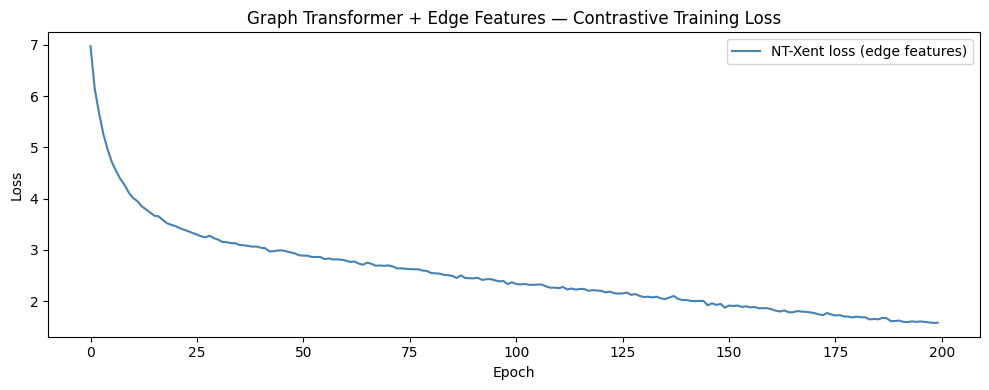

Training complete. Final loss: 1.5780


In [7]:
# retrain with edge features (train Graph Transformer with spatial edge weights)
import matplotlib.pyplot as plt
from src.models.graph_transformer import GraphTransformer
from src.training.loss import NTXentLoss
from src.training.augmentation import augment
from src.utils.seed import set_global_seed

set_global_seed(cfg["seed"])

class TrainerWithEdges:
    """Trainer that preserves edge_attr through augmentation."""

    def __init__(self, cfg, graph_data, model):
        self.cfg        = cfg
        self.graph_data = graph_data
        self.model      = model
        self.loss_fn    = NTXentLoss(temperature=cfg["training"]["contrastive"]["temperature"])
        self.optimizer  = torch.optim.AdamW(
            model.parameters(),
            lr=cfg["training"]["lr"],
            weight_decay=cfg["training"]["weight_decay"],
        )
        self.epochs    = cfg["training"]["epochs"]
        self.patience  = cfg["training"]["patience"]
        self.log_every = cfg["logging"]["log_every_n"]
        self.history   = []

    def train(self):
        aug_cfg   = self.cfg["training"]["contrastive"]
        best_loss = float("inf")
        patience  = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()

            v1 = augment(self.graph_data, aug_cfg["augment_drop_feat"],
                         aug_cfg["augment_drop_edge"])
            v2 = augment(self.graph_data, aug_cfg["augment_drop_feat"],
                         aug_cfg["augment_drop_edge"])

            # pass edge_attr aligned to the surviving edges
            ea1 = self.graph_data.edge_attr[
                torch.isin(torch.arange(self.graph_data.edge_index.shape[1]),
                torch.where(v1.edge_index[0].unsqueeze(1) ==
                self.graph_data.edge_index[0])[0])
            ] if self.graph_data.edge_attr is not None else None

            z1 = self.model(v1.x, v1.edge_index, edge_attr=self.graph_data.edge_attr[:v1.edge_index.shape[1]])
            z2 = self.model(v2.x, v2.edge_index, edge_attr=self.graph_data.edge_attr[:v2.edge_index.shape[1]])

            loss = self.loss_fn(z1, z2)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            self.history.append(loss.item())

            if epoch % self.log_every == 0:
                print(f"Epoch {epoch:>4d}/{self.epochs}  loss={loss.item():.4f}")

            if loss.item() < best_loss - 1e-4:
                best_loss = loss.item()
                patience  = 0
            else:
                patience += 1
                if patience >= self.patience:
                    print(f"Early stopping at epoch {epoch}.")
                    break

        return self.history

model_edge = GraphTransformer(
    input_dim  = cfg["models"]["input_dim"],
    hidden_dim = cfg["models"]["hidden_dim"],
    output_dim = cfg["models"]["output_dim"],
    n_layers   = cfg["models"]["graph_transformer"]["n_layers"],
    n_heads    = cfg["models"]["graph_transformer"]["n_heads"],
    dropout    = cfg["models"]["dropout"],
    edge_dim   = 1,
)

trainer = TrainerWithEdges(cfg, graph_data, model_edge)
history = trainer.train()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history, color="steelblue", linewidth=1.5, label="NT-Xent loss (edge features)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Graph Transformer + Edge Features — Contrastive Training Loss")
ax.legend()
plt.tight_layout()
plt.savefig("figures/training/graph_transformer_edge_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Training complete. Final loss: {history[-1]:.4f}")

Saved: outputs/checkpoints/graph_transformer_edge.pt


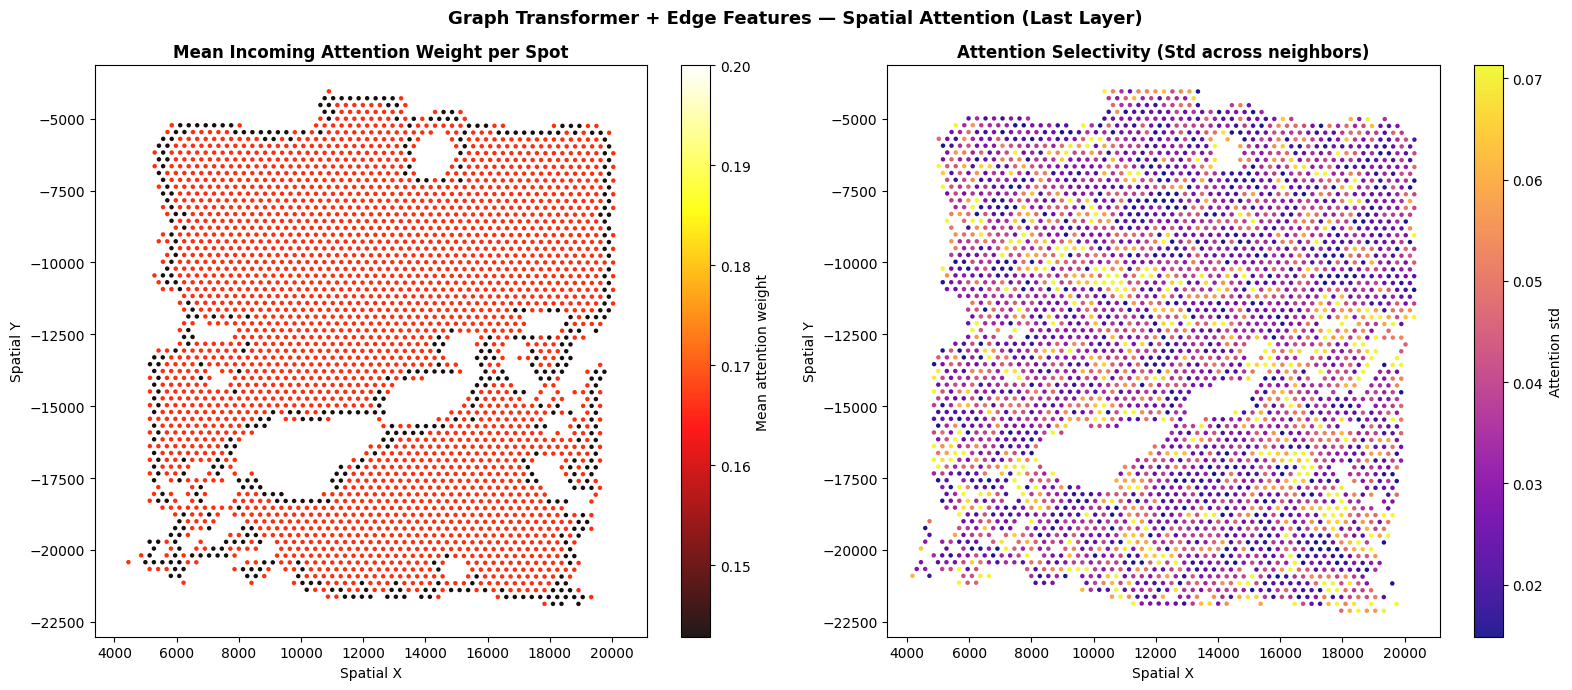

Mean attention : 0.1705 +/- 0.0334
Mean selectivity (std): 0.0378 +/- 0.0183


In [8]:
# extract and plot attention (save edge model and visualize attention selectivity)
import torch.nn.functional as F

torch.save(model_edge.state_dict(), "outputs/checkpoints/graph_transformer_edge.pt")
print("Saved: outputs/checkpoints/graph_transformer_edge.pt")

coords  = adata.obsm["spatial"]

model_edge.eval()
with torch.no_grad():
    _ = model_edge(graph_data.x, graph_data.edge_index,
                   edge_attr=graph_data.edge_attr)

edge_idx, attn = model_edge.attention_weights[-1]
attn_mean  = attn.abs().mean(dim=1).numpy()
dst_nodes  = edge_idx[1].numpy()

attn_score = np.zeros(adata.n_obs)
count      = np.zeros(adata.n_obs)
np.add.at(attn_score, dst_nodes, attn_mean)
np.add.at(count,      dst_nodes, 1)
attn_score = attn_score / np.maximum(count, 1)

# measure selectivity: std of attention weights per destination node
attn_std = np.zeros(adata.n_obs)
for node in range(adata.n_obs):
    mask = dst_nodes == node
    if mask.sum() > 1:
        attn_std[node] = attn[mask].abs().mean(dim=1).numpy().std()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc0 = axes[0].scatter(
    coords[:, 0], -coords[:, 1],
    c=attn_score, cmap="hot", s=5, alpha=0.9,
    vmin=np.percentile(attn_score, 5),
    vmax=np.percentile(attn_score, 95),
)
axes[0].set_title("Mean Incoming Attention Weight per Spot", fontweight="bold")
axes[0].set_xlabel("Spatial X")
axes[0].set_ylabel("Spatial Y")
plt.colorbar(sc0, ax=axes[0], label="Mean attention weight")

sc1 = axes[1].scatter(
    coords[:, 0], -coords[:, 1],
    c=attn_std, cmap="plasma", s=5, alpha=0.9,
    vmin=np.percentile(attn_std, 5),
    vmax=np.percentile(attn_std, 95),
)
axes[1].set_title("Attention Selectivity (Std across neighbors)", fontweight="bold")
axes[1].set_xlabel("Spatial X")
axes[1].set_ylabel("Spatial Y")
plt.colorbar(sc1, ax=axes[1], label="Attention std")

plt.suptitle("Graph Transformer + Edge Features — Spatial Attention (Last Layer)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/attention/spatial_attention_edge.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Mean attention : {attn_score.mean():.4f} +/- {attn_score.std():.4f}")
print(f"Mean selectivity (std): {attn_std.mean():.4f} +/- {attn_std.std():.4f}")